# Audio Binary Classification

In [69]:
import os
import numpy as np
import pandas as pd
import librosa
import noisereduce as nr
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import shap

## Plot and evaluate funcs

In [41]:
def evaluate_model(y_true, y_pred, title, average='macro'):
    print(f"\n{title}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))
    print("\nОтчёт по классам:\n", classification_report(y_true, y_pred))


In [87]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок {title}')
    plt.show()


## Read data

In [ ]:
path = '/Users/albertzagibin/Documents/University/ML/7 sem/Audio/data/'

In [22]:
SAMPLE_RATE = 16000 # Standard rate for speech models
DURATION = 3 # seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

## Funcs for extract features from wav

In [23]:
def PreprocessAudio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        
        # trim silence
        y, _ = librosa.effects.trim(y)
        
        # reduce noise
        y = nr.reduce_noise(y=y, sr=sr)
        
        # normalize
        y = librosa.util.normalize(y)

        # padding/truncating
        if len(y) < SAMPLES_PER_TRACK:
            y = np.pad(y, (0, SAMPLES_PER_TRACK - len(y)))
        else:
            y = y[:SAMPLES_PER_TRACK]

        return y, sr
    except Exception as error:
        print(f"Failed to process '{file_path}': {error}")
        return None, None



In [24]:
def ExtractAudioFeatures(file_path):
    audio_signal, sample_rate = PreprocessAudio(file_path)
    if audio_signal is None:
        return None

    n_fft = 2048  # means 2048 samples per window (~128ms if sr=16k)
    hop_length = 512  # means we move 512 samples forward for next window (~32ms)
    
    mfcc = librosa.feature.mfcc(y=audio_signal, sr=sample_rate, n_mfcc=13, hop_length=hop_length, n_fft=n_fft)
    mfcc_mean = np.mean(mfcc, axis=1)

    rolloff = librosa.feature.spectral_rolloff(y=audio_signal, sr=sample_rate, hop_length=hop_length, n_fft=n_fft)[0]
    rolloff_mean = np.mean(rolloff)

    zcr = librosa.feature.zero_crossing_rate(y=audio_signal, hop_length=hop_length)[0]
    zcr_mean = np.mean(zcr)

    centroid = librosa.feature.spectral_centroid(y=audio_signal, sr=sample_rate, hop_length=hop_length, n_fft=n_fft)[0]
    centroid_mean = np.mean(centroid)

    rms = librosa.feature.rms(y=audio_signal, hop_length=hop_length)[0]
    rms_mean = np.mean(rms)

    combined_features = np.hstack([
        mfcc_mean,
        rolloff_mean,
        zcr_mean,
        centroid_mean,
        rms_mean
    ])

    return combined_features

## Read data

In [25]:
data = []
labels = []

In [28]:
data = []
labels = []

for label in ['male', 'female'] :
    folder_path = os.path.join(f'{path}', label)

    files = os.listdir(folder_path)

    for file_name in tqdm(files, desc=f"Processing {label}"):
        file_path = os.path.join(folder_path, file_name)

        if file_path.lower().endswith(('.wav', '.mp3')):
            features = ExtractAudioFeatures(file_path)
            if features is not None:
                data.append(features)
                labels.append(label)

Processing female: 100%|██████████| 5768/5768 [01:55<00:00, 50.08it/s]


In [29]:
feature_columns = ([f"mfcc_{i+1}" for i in range(13)] +["spectral_rolloff", "zero_crossing_rate", "spectral_centroid", "rms"])

In [30]:
df = pd.DataFrame(data, columns=feature_columns)
df['gender'] = labels

In [34]:
df.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_rolloff,zero_crossing_rate,spectral_centroid,rms,gender
0,-374.248047,35.252251,24.682081,55.227985,10.448344,-2.671383,-10.081048,-5.205328,-15.996962,-4.506874,-4.817358,-5.940652,-2.286738,3570.894282,0.210054,2346.231363,0.080222,male
1,-529.444153,3.786150,12.856445,17.258913,-2.664770,5.513779,0.430678,5.927711,-4.101618,1.287166,-0.033646,-1.006328,-3.373990,1691.406250,0.051690,887.271487,0.022732,male
2,-356.640717,99.316971,-2.916433,66.045273,2.528779,-3.099081,-15.755103,-18.808195,0.144515,-18.002865,-8.190319,-0.459261,-11.417709,2964.511303,0.173106,1886.530381,0.070690,male
3,-381.443726,60.989262,4.456474,39.768585,-4.049476,1.489966,-8.103431,-1.958426,0.464598,-14.913976,0.436110,-2.103409,-9.751396,2531.665559,0.173194,1616.088518,0.066505,male
4,-370.490021,42.830914,20.994089,34.504326,-5.216997,-1.983864,-14.938352,-5.546728,-7.929483,2.382549,-19.876236,-2.530839,-2.035396,3551.612367,0.208475,2236.788811,0.051188,male


## EDA

In [31]:
print("Number of Duplicates:", df.duplicated().sum())
print(f"Percentage of Duplicates: {df.duplicated().sum() / len(df) * 100:.2f}%")

Number of Duplicates: 1078
Percentage of Duplicates: 6.68%


In [32]:
df = df.drop_duplicates()
print("Dropped Duplicates")
print(f"Percentage of Duplicates: {df.duplicated().sum() / len(df) * 100:.2f}%")
print("Data Shape:", df.shape)

Dropped Duplicates
Percentage of Duplicates: 0.00%
Data Shape: (15070, 18)


In [59]:
df['gender'].value_counts()

gender
1    9841
0    5229
Name: count, dtype: int64

In [60]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

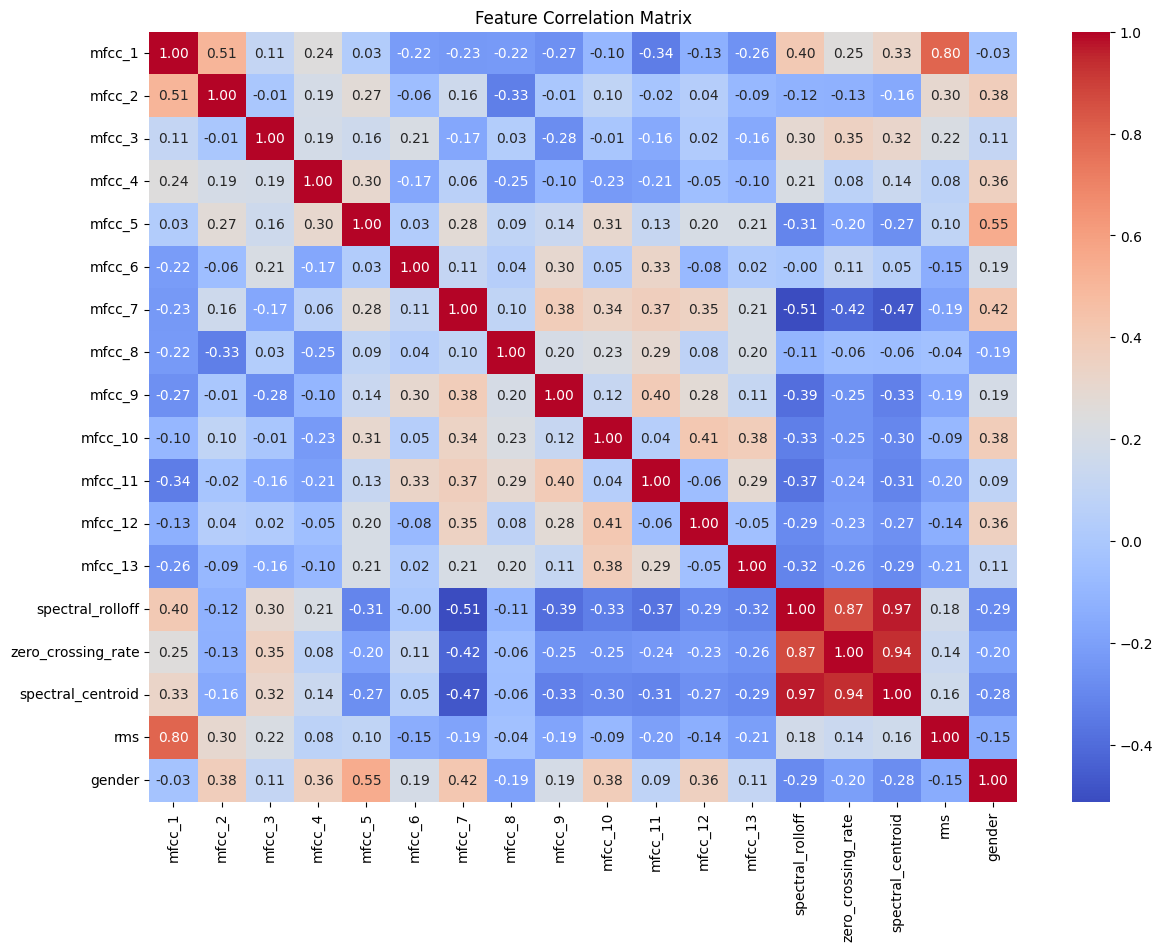

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [61]:
X = df.drop('gender', axis=1)
y = df['gender']

## Train models

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [108]:
log_reg = LogisticRegression(solver="liblinear",
    max_iter=1000,
    C=1.0)

log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



LogisticRegression
Accuracy : 0.9343
Precision: 0.9523
Recall   : 0.9495
F1-score : 0.9509

Отчёт по классам:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90       994
           1       0.95      0.95      0.95      2020

    accuracy                           0.93      3014
   macro avg       0.93      0.93      0.93      3014
weighted avg       0.93      0.93      0.93      3014



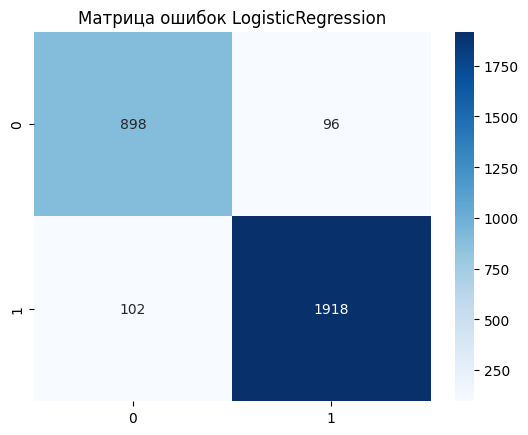

In [109]:
evaluate_model(y_test, y_pred_lr, 'LogisticRegression')
plot_confusion_matrix(y_test, y_pred_lr, 'LogisticRegression')

### Random Forest Classifier

In [66]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)


Random Forest
Accuracy : 0.9648
Precision: 0.971
Recall   : 0.9767
F1-score : 0.9738

Отчёт по классам:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       994
           1       0.97      0.98      0.97      2020

    accuracy                           0.96      3014
   macro avg       0.96      0.96      0.96      3014
weighted avg       0.96      0.96      0.96      3014



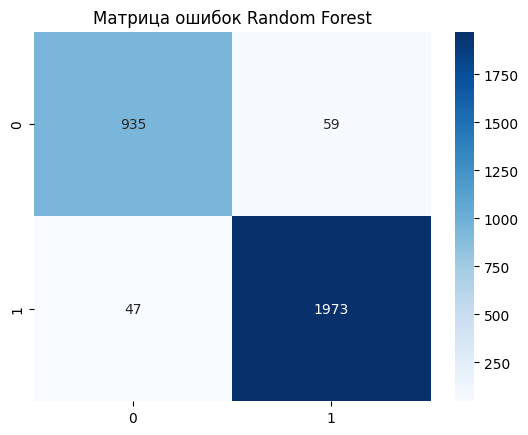

In [90]:
evaluate_model(y_test, y_pred_rf, 'Random Forest')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

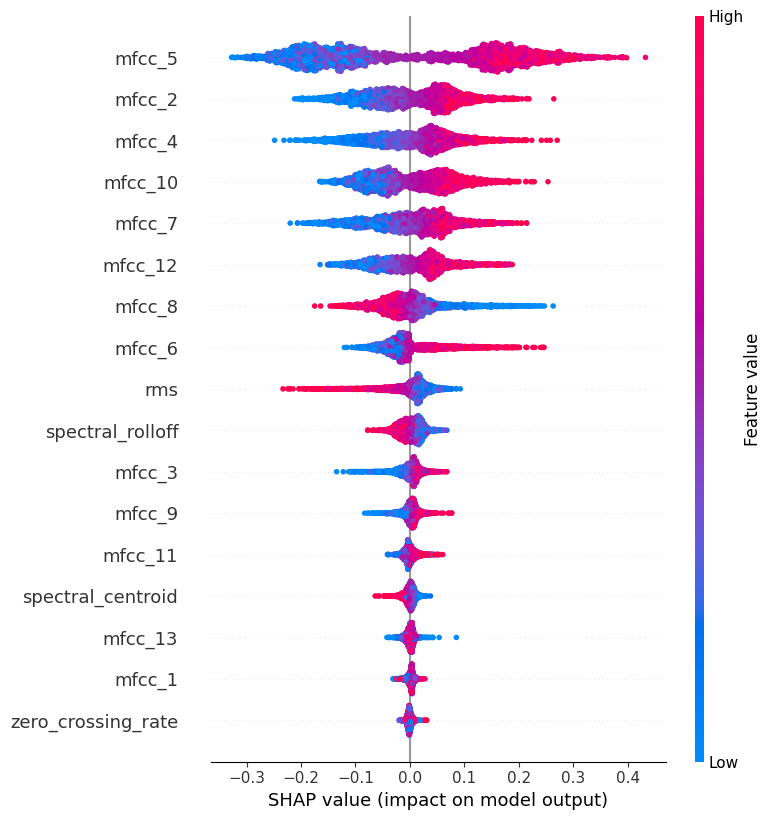

In [ ]:
explainer = shap.TreeExplainer(rf_clf)
feature_names = X_train.columns
shap_values_test = explainer.shap_values(X_test_scaled)

shap_values_class_1 = shap_values_test[:, :, 1]

shap.summary_plot(
    shap_values_class_1,
    X_test_scaled,
    feature_names=feature_names
)
